In [3]:
from pathlib import Path
import pandas as pd
from pesto_tracker import PESTOTracker


In [5]:
STEP_SIZE =0.01
SAMPLE_RATE =44100
f0Pesto_tracker = PESTOTracker(use_gpu=False, step_size=STEP_SIZE, sample_rate=SAMPLE_RATE)

stems_folder = Path("../SourceSeparation/demucs_output")
wav_files = list(stems_folder.glob("**/voice.wav"))
print(f"{len(wav_files)} vocal stems found.")

f0_automatic_annotations_folder = Path("../data/cante2midi_f0/")
autogt_f0_files = list(f0_automatic_annotations_folder.glob("*.csv"))

f0_groundtruth_folder = Path("../data/cante2midi_groundTruth")
gt_f0_files = list(f0_groundtruth_folder.glob("*.csv"))

paired_data = {}

for file in wav_files:
    print(file)
    file_name= file.parent.stem
    idx = file_name.split('_')[0]
    gt_file = list(f0_groundtruth_folder.glob(f"{file_name}.notes"))[0]
    autogt_file = list(f0_automatic_annotations_folder.glob(f"{file_name}.f0.csv"))[0]

    final_pitches, timesteps, confidence = f0Pesto_tracker.extract_f0(file)

    paired_data[idx]= {'stem':file,
                       'gt':gt_file,
                       'autogt':autogt_file,
                       'PESTO': {
                           'pitch':final_pitches,
                           'timesteps':timesteps,
                           'confidence':confidence
                       }
                    }
    


5 vocal stems found.
../SourceSeparation/demucs_output/08_PericonDeCadiz_MeMetieronEnUnVapor/voice.wav
../SourceSeparation/demucs_output/05_Antonio Mairena_Verguenza/voice.wav
../SourceSeparation/demucs_output/15_ChatoDeLaIsla_SoloEnElMundo/voice.wav
../SourceSeparation/demucs_output/02_BernardoElDeLosLobitos_LosPecesMueranDePena/voice.wav
../SourceSeparation/demucs_output/01_GabrielMoreno_YoNoTeHeDaoMotivos/voice.wav


In [6]:
def noteToFreq(note):
    a = 440 #frequency of A (coomon value is 440Hz)
    return (a / 32) * (2 ** ((note - 9) / 12))

In [24]:
annotations_05 = pd.read_csv(paired_data['05']['gt'], sep=",", names = ['onset_time', 'duration', 'midinote', 'vel'], index_col=False)
annotations_05['freq'] = annotations_05.midinote.apply(lambda x: noteToFreq(x))
predicted_05 = pd.DataFrame(data={
    'timestamp':paired_data['05']['PESTO']['timesteps']*STEP_SIZE/10,
    'freq': paired_data['05']['PESTO']['pitch'],
    'confidence':paired_data['05']['PESTO']['confidence']
})

print(f"Annotated landmarks: {len(annotations_05)}")
print(f"Tracked f0: {len(predicted_05)}")

Annotated landmarks: 165
Tracked f0: 10695


In [28]:
STEP_SIZE

0.01

In [26]:
paired_data['05']['PESTO']['timesteps']

array([0.0000e+00, 1.0000e+01, 2.0000e+01, ..., 1.0692e+05, 1.0693e+05,
       1.0694e+05], shape=(10695,), dtype=float32)

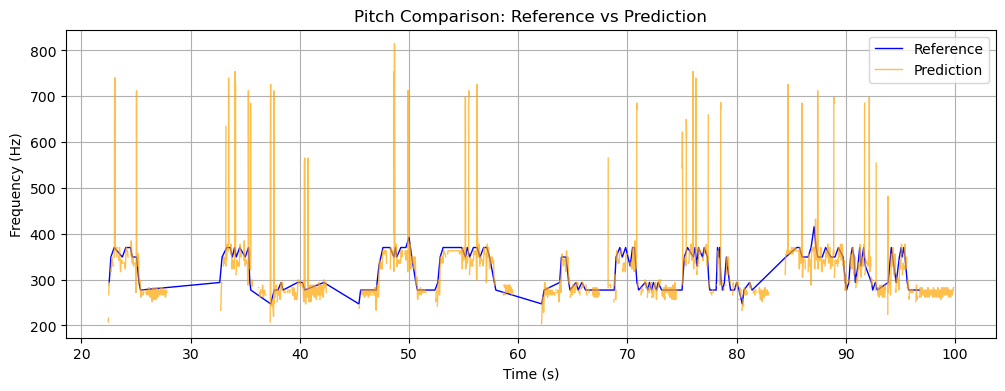

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example: load your CSVs
# ref_df = pd.read_csv("reference.csv")  # columns: timestamp, freq
# pred_df = pd.read_csv("prediction.csv")  # columns: timestamp, freq

# Replace -220 with NaN for plotting
annotations_05['freq_plot'] = annotations_05['freq'].replace(-220.0, np.nan)
predicted_05['freq_plot'] = predicted_05['freq'].replace(0.0, np.nan)


# Create figure
plt.figure(figsize=(12, 4))

# Plot reference
plt.plot(annotations_05['onset_time'], annotations_05['freq_plot'], label='Reference', color='blue', linewidth=1)

# Plot predictions
plt.plot(predicted_05['timestamp'], predicted_05['freq_plot'], label='Prediction', color='orange', alpha=0.7, linewidth=1)

# Labels
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Comparison: Reference vs Prediction')
plt.legend()
plt.grid(True)
#plt.xlim(0, 5)  # first 5 seconds
plt.show()

### Singe wav PESTO analysis

In [3]:
import torchaudio
import pesto
import torch
import soundfile as sf

wav, sr = sf.read(wav_files[0])
wav = torch.tensor(wav).float()

print(sr)
# convert to channels x samples
if wav.ndim == 1:
    wav = wav.unsqueeze(0)
else:
    wav = wav.T

# Load audio (ensure mono; stereo channels are treated as separate batch dimensions)
#x, sr = torchaudio.load(wa)
wav = wav.mean(dim=0)  # PESTO takes mono audio as input

# Predict pitch. x can be (num_samples) or (batch, num_samples)
timesteps, pitch, confidence, activations = pesto.predict(wav, sr, step_size=5)

# Predicting from multiple files:
#pesto.predict_from_files(["example1.wav", "example2.mp3"], export_format=["csv"])

44100


In [ ]:
print(len(timesteps))
import numpy as np
step_size=1
pitch = np.where(confidence < 0.5, -220, pitch)

f0_pred = pd.DataFrame(data={
    'timestamp':timesteps* (step_size / 1000.0),
    'freq': pitch,
    'confidence':confidence
})
f0_pred

PosixPath('/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/SourceSeparation/demucs_output/08_PericonDeCadiz_MeMetieronEnUnVapor/voice.wav')

In [6]:
import pandas as pd
folder = Path("/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/data/cante2midi_f0/")
gt_f0_files = list(folder.glob("*.csv"))
f0_ref = pd.read_csv(gt_f0_files[6], names=['timestamp', 'freq'])
f0_ref

,timestamp,freq
0,0.023220,-220.0
1,0.026122,-220.0
2,0.029025,-220.0
3,0.031927,-220.0
4,0.034830,-220.0
...,...,...
57581,167.151746,-220.0
57582,167.154649,-220.0
57583,167.157551,-220.0
57584,167.160454,-220.0


,timestamp,freq,freq_plot
0,0.023220,-220.0,NaN
1,0.026122,-220.0,NaN
2,0.029025,-220.0,NaN
3,0.031927,-220.0,NaN
4,0.034830,-220.0,NaN
...,...,...,...
57581,167.151746,-220.0,NaN
57582,167.154649,-220.0,NaN
57583,167.157551,-220.0,NaN
57584,167.160454,-220.0,NaN


In [8]:
f0_pred

,timestamp,freq,confidence
0,0.000000,-220.0,0.090661
1,0.005000,-220.0,0.077913
2,0.010000,-220.0,0.070254
3,0.015000,-220.0,0.066402
4,0.020000,-220.0,0.051932
...,...,...,...
33289,166.445007,-220.0,0.070539
33290,166.450012,-220.0,0.067382
33291,166.455002,-220.0,0.068469
33292,166.460007,-220.0,0.070823


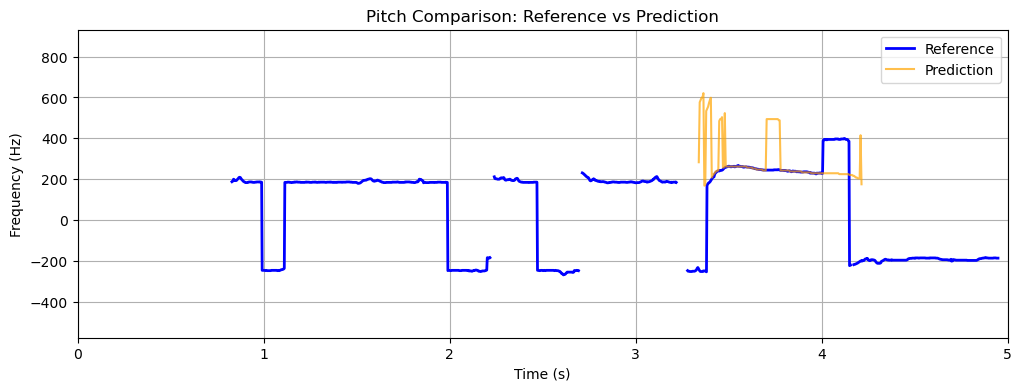

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example: load your CSVs
# ref_df = pd.read_csv("reference.csv")  # columns: timestamp, freq
# pred_df = pd.read_csv("prediction.csv")  # columns: timestamp, freq

# Replace -220 with NaN for plotting
f0_ref['freq_plot'] = f0_ref['freq'].replace(-220.0, np.nan)
f0_pred['freq_plot'] = f0_pred['freq'].replace(-220.0, np.nan)

# Create figure
plt.figure(figsize=(12, 4))

# Plot reference
plt.plot(f0_ref['timestamp'], f0_ref['freq_plot'], label='Reference', color='blue', linewidth=2)

# Plot predictions
plt.plot(f0_pred['timestamp'], f0_pred['freq_plot'], label='Prediction', color='orange', alpha=0.7)

# Labels
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Comparison: Reference vs Prediction')
plt.legend()
plt.grid(True)
plt.xlim(0, 5)  # first 5 seconds
plt.show()